# ATIIS p0 sweep: comparative analysis

Manifest-driven analysis of the belief (`p0`) sweep and its OFAT validation arms.

- **Headline** (the `baseline` arm, all models x scenarios): does the LLM blame
  curve track the formal Shapley oracle? Shape (rank) agreement, an explicit
  non-monotonicity test, the blame-vs-p0 curves, and a variance decomposition
  (parameter vs wording).
- **Validation** (s01 only, per arm): does the curve shift the way the oracle
  shifts when one variable changes? `vote` (Wilcoxon + McNemar), `alpha`
  (peak-location shift + Mann-Whitney), `cost`/`stakes` (Mann-Whitney + slope vs
  the model's own inferred cost). Plus `oracle_at_inferred` agreement everywhere.

All tables are written to `analysis/tables/` (CSV + LaTeX) and figures to
`analysis/figures/` for embedding in the report.

## Main findings (summary)

Full grid ran clean: 14 self-describing runs, 2940 calls, 0 errors. The headline p0 sweep is complete for all 3 models x 3 scenarios; the validation arms were run for **qwen / s01 only**, so every vote/alpha/cost/stakes result rests on a single model and should be read as indicative, not confirmatory.

**1. The belief variable is read correctly.** Mean `inferred_probability` rises monotonically across the seven p0 levels (about 13 to 90), so nothing below is a comprehension failure of the swept variable.

**2. Blame tracks the oracle's non-monotone shape, not the surface action.** The oracle peaks at *somewhat-low* p0 (rank 2) and collapses toward certainty (about 0.13 down to 0.002). Section 2.1: all 9 model x scenario cells correlate **positively** with `oracle_at_reference` (8 of 9 significant after BH; strongest qwen/s01 at rho = +0.53). Section 2.2: the quadratic term is **negative in all 9 cells** (significant in 7/9) and the fitted LLM peak sits at rank 2-3 against the oracle's rank 2 a genuine interior hump, not blame rising with confidence. The mixed model (2.4) shows the same arc: blame peaks at *even* and drops about 8 points at *very_high*.

**3. The match is qualitative, not quantitative.** The oracle's peak-to-trough range is roughly 60x; the models compress it to about 1.3-1.8x. Feeding each model its own inferred p0/alpha/cost (`spearman_inferred` in 2.1) gives **weaker** agreement than the nominal reference mapping, so blame is not a clean function of the quantities the model reports reasoning from. Parameter share of variance (2.4) is modest (about 0.06-0.36) and wording share is small the signal is real but weak.

**4. Validation arms (qwen/s01) are mixed.**
- `vote_yes` (3.1): large significant drop (Wilcoxon p ~ 1e-25), correct direction, but the no/yes blame ratio is only **1.37 vs the oracle's ~3.3**, and McNemar b = c = 0 **no yes-voter is ever exonerated to zero**. Surface action is under-weighted relative to the oracle.
- `alpha` (3.2): the **peak shifts in the oracle's direction** (negligible moves the peak to rank 3, strong to rank 1, both matching the oracle), both Mann-Whitney significant the best-behaved axis.
- `stakes_high` (3.3): correct direction but weak (MWU p = 0.018, equal medians).
- `cost_trivial` (3.3): **null** (MWU p = 0.32) no sensitivity to switch cost.

**Bottom line.** The models show the qualitative signature of counterfactual (Shapley) blame non-monotone in belief, declining toward certainty, sensitive to vote and to lobbying-effectiveness and this is not an artifact of misreading inputs. But they are quantitatively miscalibrated: compressed dynamic range, over-blaming the blameless (will not zero a correct vote), and insensitive to cost. Scenario framing matters: the cold corporate-board skin (s03) is the weakest tracker (gemini/s03 rho = +0.10, n.s.), the affect-laden health skin the strongest.


## 0  Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Make `engine` and `analysis` importable whether the notebook runs from the
# experiment root or from analysis/.
HERE = Path.cwd()
EXP_ROOT = HERE if (HERE / "engine").exists() else HERE.parent
sys.path.insert(0, str(EXP_ROOT))

from analysis.loader import load_runs, P0_LEVEL_ORDER

FIG = EXP_ROOT / "analysis" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
TAB = EXP_ROOT / "analysis" / "tables"; TAB.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(0)

In [2]:
def spearman(x, y):
    return stats.spearmanr(x, y).statistic

def bootstrap_ci(stat_fn, *arrays, n=2000, alpha=0.05):
    """Percentile bootstrap CI for a statistic over paired arrays."""
    arrays = [np.asarray(a, float) for a in arrays]
    m = len(arrays[0]); idx = np.arange(m); vals = []
    for _ in range(n):
        s = RNG.choice(idx, m, replace=True)
        try:
            vals.append(stat_fn(*[a[s] for a in arrays]))
        except Exception:
            pass
    if not vals:
        return np.nan, np.nan
    return tuple(np.nanpercentile(vals, [100 * alpha / 2, 100 * (1 - alpha / 2)]))

def bh(pvals):
    """Benjamini-Hochberg adjusted p-values (scipy >= 1.11, with a fallback)."""
    p = np.asarray(pvals, float)
    try:
        return stats.false_discovery_control(p, method="bh")
    except Exception:
        order = np.argsort(p); ranked = np.empty_like(p); m = len(p); cummin = 1.0
        for i in range(m - 1, -1, -1):
            cummin = min(cummin, p[order[i]] * m / (i + 1))
            ranked[order[i]] = cummin
        return ranked

def save_table(df, name):
    df.to_csv(TAB / f"{name}.csv", index=False)
    fmt = lambda v: f"{v:.3f}" if isinstance(v, float) else str(v)
    (TAB / f"{name}.tex").write_text(df.to_latex(index=False, float_format="%.3f"))
    print(f"wrote tables/{name}.csv + .tex")
    return df

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")
    print(f"wrote figures/{name}.png")
    plt.show()

## 1  Load runs

In [3]:
df = load_runs(sweep="sweep1_p0")
df["arm"] = df["arm"].astype(str)
base = df[df["arm"] == "baseline"].copy()                  # headline
print("calls per (model, scenario, arm):")
print(df.groupby(["model_slug", "scenario", "arm"]).size())

calls per (model, scenario, arm):
model_slug              scenario    arm             
gemini-2.5-flash        s01_health  baseline            210
                        s02_grant   baseline            210
                        s03_board   baseline            210
llama-3.3-70b-instruct  s01_health  baseline            210
                        s02_grant   baseline            210
                        s03_board   baseline            210
qwen3-235b-a22b-2507    s01_health  alpha_negligible    210
                                    alpha_strong        210
                                    baseline            210
                                    cost_trivial        210
                                    stakes_high         210
                                    vote_yes            210
                        s02_grant   baseline            210
                        s03_board   baseline            210
dtype: int64


## 2  Headline: does LLM blame track the oracle?

### 2.1  Rank (shape) agreement with the oracle

In [4]:
rows = []
for (m, s), g in base.groupby(["model_slug", "scenario"]):
    blame = g["blameworthiness"].to_numpy(float)
    o_ref = g["oracle_at_reference"].to_numpy(float)
    o_inf = g["oracle_at_inferred"].to_numpy(float)
    rho = spearman(blame, o_ref)
    lo, hi = bootstrap_ci(spearman, blame, o_ref)
    rows.append(dict(
        model=m, scenario=s, n=len(g),
        spearman_ref=rho, ci_lo=lo, ci_hi=hi,
        p=stats.spearmanr(blame, o_ref).pvalue,
        spearman_inferred=spearman(blame, o_inf),
    ))
head = pd.DataFrame(rows)
head["p_bh"] = bh(head["p"])
save_table(head, "headline_spearman")
head

wrote tables/headline_spearman.csv + .tex


,model,scenario,n,spearman_ref,ci_lo,ci_hi,p,spearman_inferred,p_bh
0,gemini-2.5-flash,s01_health,210,0.259962,0.128157,0.398955,1.387171e-04,0.193905,2.740685e-04
1,gemini-2.5-flash,s02_grant,210,0.165180,0.020146,0.309155,1.658058e-02,0.230528,1.865315e-02
2,gemini-2.5-flash,s03_board,210,0.103678,-0.039639,0.239342,1.342619e-01,-0.037973,1.342619e-01
3,llama-3.3-70b-instruct,s01_health,210,0.279230,0.148957,0.401220,4.056949e-05,0.202196,1.217085e-04
4,llama-3.3-70b-instruct,s02_grant,210,0.258441,0.118077,0.389211,1.522603e-04,0.227357,2.740685e-04
5,llama-3.3-70b-instruct,s03_board,210,0.239363,0.104339,0.368283,4.670096e-04,0.136234,7.005144e-04
6,qwen3-235b-a22b-2507,s01_health,210,0.531488,0.421576,0.630219,1.043609e-16,0.387015,9.392480e-16
7,qwen3-235b-a22b-2507,s02_grant,210,0.175782,0.034279,0.307175,1.070996e-02,0.228214,1.376994e-02
8,qwen3-235b-a22b-2507,s03_board,210,0.358344,0.231237,0.476969,9.278711e-08,0.145997,4.175420e-07


### 2.2  Non-monotonicity test

The theory predicts a non-monotonic peak in blame vs `p0`. A bare Spearman would
miss that. Fit `blame ~ rank + rank^2` and test the quadratic term; compare the
fitted LLM peak rank to the oracle's peak rank.

In [5]:
def quad_test(g):
    x = g["level_rank"].to_numpy(float); y = g["blameworthiness"].to_numpy(float)
    X = np.column_stack([np.ones_like(x), x, x ** 2])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta; dof = len(y) - 3
    sigma2 = (resid @ resid) / dof
    se = np.sqrt(sigma2 * np.diag(np.linalg.inv(X.T @ X)))
    t = beta[2] / se[2]
    pval = 2 * stats.t.sf(abs(t), dof)
    peak = -beta[1] / (2 * beta[2]) if beta[2] != 0 else np.nan
    return beta[2], pval, peak

rows = []
for (m, s), g in base.groupby(["model_slug", "scenario"]):
    b2, pv, peak = quad_test(g)
    oracle_peak = g.groupby("level_rank")["oracle_at_reference"].mean().idxmax()
    rows.append(dict(model=m, scenario=s, quad_coef=b2, quad_p=pv,
                     llm_peak_rank=peak, oracle_peak_rank=oracle_peak))
nm = pd.DataFrame(rows)
nm["quad_p_bh"] = bh(nm["quad_p"])
save_table(nm, "headline_nonmonotonicity")
nm

wrote tables/headline_nonmonotonicity.csv + .tex


,model,scenario,quad_coef,quad_p,llm_peak_rank,oracle_peak_rank,quad_p_bh
0,gemini-2.5-flash,s01_health,-1.380952,1.510057e-07,2.463793,2,4.530172e-07
1,gemini-2.5-flash,s02_grant,-0.986111,5.707538e-05,2.236419,2,8.561307e-05
2,gemini-2.5-flash,s03_board,-0.835317,1.479292e-03,3.049169,2,1.901947e-03
3,llama-3.3-70b-instruct,s01_health,-0.781746,1.736641e-06,2.596447,2,3.125953e-06
4,llama-3.3-70b-instruct,s02_grant,-0.392857,8.328490e-02,1.439394,2,8.328490e-02
5,llama-3.3-70b-instruct,s03_board,-0.952381,2.992084e-07,2.900000,2,6.732188e-07
6,qwen3-235b-a22b-2507,s01_health,-0.893254,9.840065e-13,2.135717,2,4.428029e-12
7,qwen3-235b-a22b-2507,s02_grant,-0.230159,6.069814e-02,2.094828,2,6.828541e-02
8,qwen3-235b-a22b-2507,s03_board,-0.960317,4.160604e-14,2.758264,2,3.744543e-13


### 2.3  Blame-vs-p0 curves with oracle overlay

wrote figures/headline_curves_s01_health.png


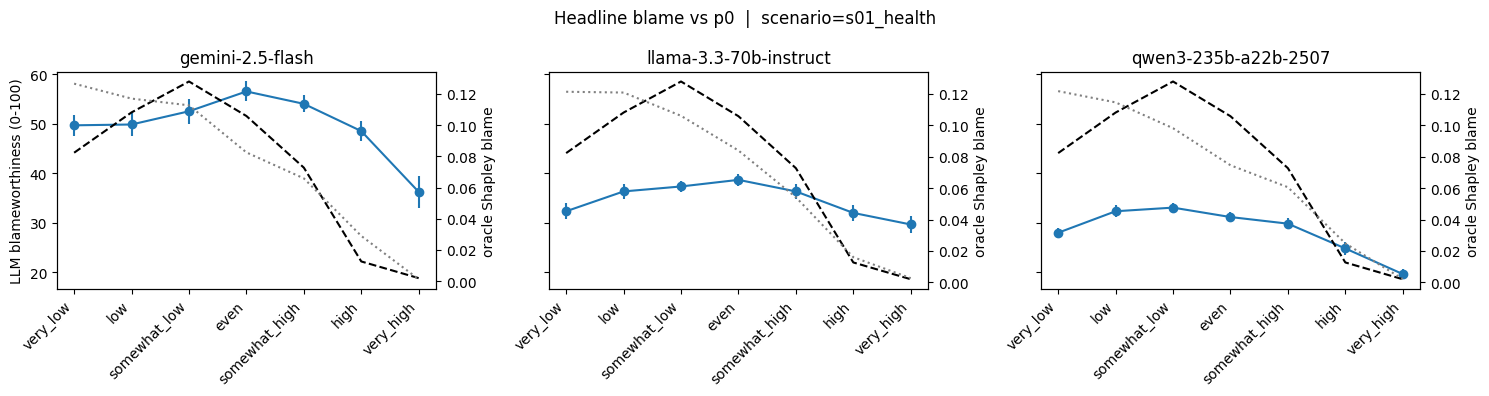

wrote figures/headline_curves_s02_grant.png


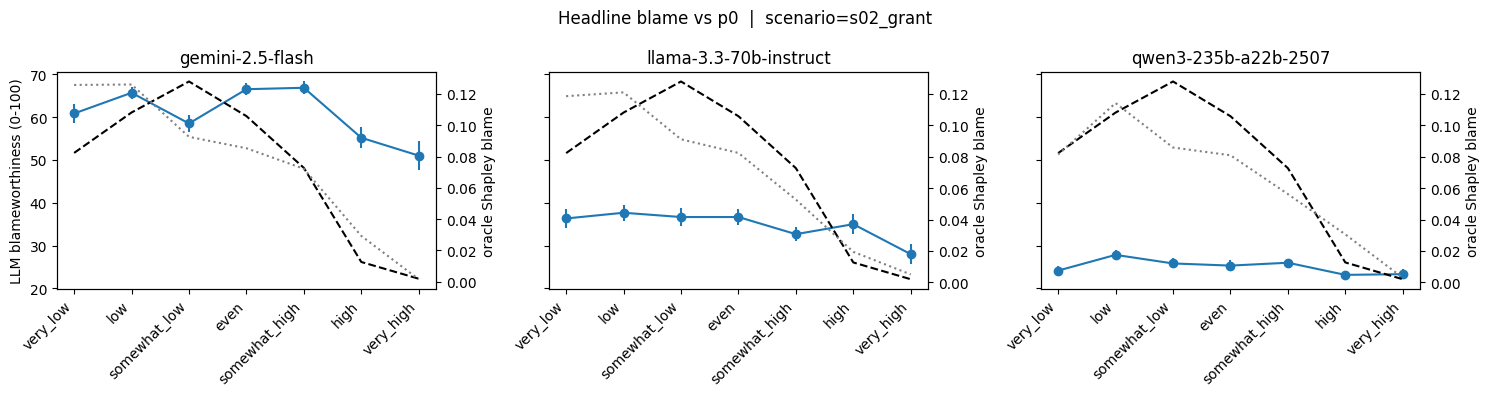

wrote figures/headline_curves_s03_board.png


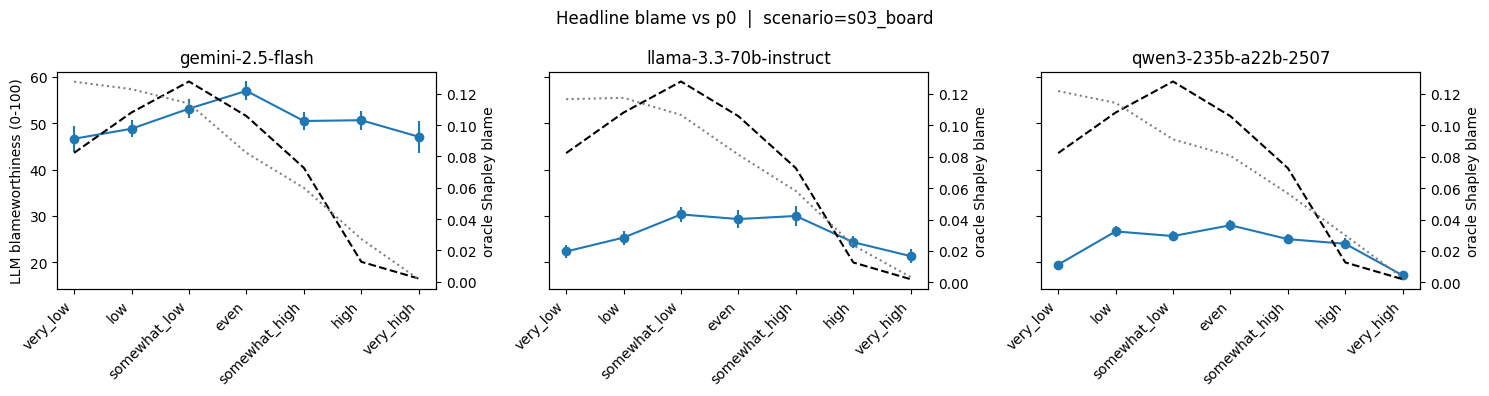

In [6]:
levels = P0_LEVEL_ORDER
for scenario, gs in base.groupby("scenario"):
    models = sorted(gs["model_slug"].unique())
    fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4),
                             sharey=True, squeeze=False)
    for ax, m in zip(axes[0], models):
        g = gs[gs["model_slug"] == m]
        gm = g.groupby("level_rank")["blameworthiness"].agg(["mean", "sem"])
        ax.errorbar(gm.index, gm["mean"], yerr=gm["sem"], marker="o", color="tab:blue",
                    label="LLM blame")
        ax.set_title(m); ax.set_xticks(range(len(levels)))
        ax.set_xticklabels(levels, rotation=45, ha="right")
        ax2 = ax.twinx()
        oref = g.groupby("level_rank")["oracle_at_reference"].mean()
        oinf = g.groupby("level_rank")["oracle_at_inferred"].mean()
        ax2.plot(oref.index, oref.values, "--", color="k", label="oracle (ref)")
        ax2.plot(oinf.index, oinf.values, ":", color="gray", label="oracle (inferred)")
        ax2.set_ylabel("oracle Shapley blame")
    axes[0][0].set_ylabel("LLM blameworthiness (0-100)")
    fig.suptitle(f"Headline blame vs p0  |  scenario={scenario}")
    savefig(f"headline_curves_{scenario}")

### 2.4  Variance decomposition (parameter vs wording)

Dependency-light ICC-style summary: the share of total blame variance explained
by the parameter (`level`) versus the phrasing within a level. A small phrasing
share means the signal is from the parameter, not the wording.

In [7]:
def variance_shares(g):
    y = g["blameworthiness"].to_numpy(float)
    gm = y.mean(); sst = ((y - gm) ** 2).sum()
    if sst == 0:
        return np.nan, np.nan
    ss_level = sum(len(gg) * (gg["blameworthiness"].mean() - gm) ** 2
                   for _, gg in g.groupby("level_rank"))
    ss_phr = 0.0
    for _, gl in g.groupby("level_rank"):
        lm = gl["blameworthiness"].mean()
        for _, gp in gl.groupby("phrasing_idx"):
            ss_phr += len(gp) * (gp["blameworthiness"].mean() - lm) ** 2
    return ss_level / sst, ss_phr / sst

rows = []
for (m, s), g in base.groupby(["model_slug", "scenario"]):
    el, ep = variance_shares(g)
    rows.append(dict(model=m, scenario=s, var_param=el, var_phrasing=ep,
                     var_resid=1 - el - ep))
vd = pd.DataFrame(rows)
save_table(vd, "headline_variance_shares")
vd

wrote tables/headline_variance_shares.csv + .tex


,model,scenario,var_param,var_phrasing,var_resid
0,gemini-2.5-flash,s01_health,0.190127,0.070138,0.739735
1,gemini-2.5-flash,s02_grant,0.196697,0.107643,0.695660
2,gemini-2.5-flash,s03_board,0.063860,0.204147,0.731993
3,llama-3.3-70b-instruct,s01_health,0.132209,0.091837,0.775954
4,llama-3.3-70b-instruct,s02_grant,0.072594,0.125150,0.802257
5,llama-3.3-70b-instruct,s03_board,0.131714,0.138717,0.729569
6,qwen3-235b-a22b-2507,s01_health,0.364220,0.071591,0.564189
7,qwen3-235b-a22b-2507,s02_grant,0.061890,0.137921,0.800189
8,qwen3-235b-a22b-2507,s03_board,0.285412,0.113742,0.600845


In [8]:
# Optional: a formal mixed model if statsmodels is available (not required).
try:
    import statsmodels.formula.api as smf
    g = base[base["scenario"] == base["scenario"].iloc[0]].copy()
    md_fit = smf.mixedlm("blameworthiness ~ C(level)", g, groups=g["phrasing_idx"]).fit()
    print(md_fit.summary())
except Exception as exc:
    print("statsmodels MixedLM skipped (use section 2.4 instead):", exc)

                Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   blameworthiness
No. Observations:     630       Method:               REML           
No. Groups:           3         Scale:                167.7998       
Min. group size:      210       Log-Likelihood:       -2495.5264     
Max. group size:      210       Converged:            Yes            
Mean group size:      210.0                                          
---------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
---------------------------------------------------------------------
Intercept                 36.667    1.369 26.785 0.000  33.984 39.350
C(level)[T.low]            2.833    1.931  1.467 0.142  -0.951  6.618
C(level)[T.somewhat_low]   4.300    1.931  2.227 0.026   0.515  8.085
C(level)[T.even]           5.444    1.931  2.819 0.005   1.660  9.229
C(level)[T.somewhat_high]  3.389    

/home/rcrtss/.pyenv/versions/dev-atiis/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/rcrtss/.pyenv/versions/dev-atiis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/rcrtss/.pyenv/versions/dev-atiis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/rcrtss/.pyenv/versions/dev-atiis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


## 3  Validation arms (s01): does the curve shift like the framework?

Each arm changes one held variable. We check the LLM curve moves the way the
oracle curve moves.

In [9]:
S = "s01_health"
val = df[df["scenario"] == S].copy()
ARMS_PRESENT = sorted(val["arm"].unique())
print("arms present in", S, ":", ARMS_PRESENT)

arms present in s01_health : ['alpha_negligible', 'alpha_strong', 'baseline', 'cost_trivial', 'stakes_high', 'vote_yes']


### 3.1  Own vote (`vote_yes`)

H0: the yes-voter gets zero blame. Wilcoxon signed-rank pairs no vs yes by
(level, phrasing, rep); McNemar tests the binary `blame==0` for the yes-voter;
the blame ratio is compared to the oracle's (about 3.3).

In [10]:
rows = []
for m, g in val.groupby("model_slug"):
    b = g[g["arm"] == "baseline"]; y = g[g["arm"] == "vote_yes"]
    if y.empty:
        continue
    key = ["level", "phrasing_idx", "rep"]
    merged = b.merge(y, on=key, suffixes=("_no", "_yes"))
    if merged.empty:
        continue
    w = stats.wilcoxon(merged["blameworthiness_no"], merged["blameworthiness_yes"],
                       zero_method="zsplit")
    no0 = merged["blameworthiness_no"] == 0; yes0 = merged["blameworthiness_yes"] == 0
    bb = int((~no0 & yes0).sum()); cc = int((no0 & ~yes0).sum())
    chi = (abs(bb - cc) - 1) ** 2 / (bb + cc) if (bb + cc) else np.nan
    mcp = stats.chi2.sf(chi, 1) if (bb + cc) else np.nan
    ratio = merged["blameworthiness_no"].mean() / max(merged["blameworthiness_yes"].mean(), 1e-9)
    rows.append(dict(model=m, n_pairs=len(merged),
                     median_no=merged["blameworthiness_no"].median(),
                     median_yes=merged["blameworthiness_yes"].median(),
                     wilcoxon_p=w.pvalue, mcnemar_b=bb, mcnemar_c=cc, mcnemar_p=mcp,
                     blame_ratio=ratio, oracle_ratio=3.3))
vote = pd.DataFrame(rows)
if not vote.empty:
    vote["wilcoxon_p_bh"] = bh(vote["wilcoxon_p"])
    save_table(vote, "validation_vote")
vote

wrote tables/validation_vote.csv + .tex


,model,n_pairs,median_no,median_yes,wilcoxon_p,mcnemar_b,mcnemar_c,mcnemar_p,blame_ratio,oracle_ratio,wilcoxon_p_bh
0,qwen3-235b-a22b-2507,210,30.0,20.0,1.659361e-25,0,0,NaN,1.368578,3.3,1.659361e-25


### 3.2  Pressure effectiveness (`alpha_negligible`, `alpha_strong`)

The framework moves the peak location of the p0 curve as alpha changes. Compare
the LLM peak shift to the oracle peak shift; Mann-Whitney tests the overall
distribution shift vs baseline.

In [11]:
rows = []
for m, g in val.groupby("model_slug"):
    base_g = g[g["arm"] == "baseline"]
    for arm in ["alpha_negligible", "alpha_strong"]:
        a = g[g["arm"] == arm]
        if a.empty or base_g.empty:
            continue
        u = stats.mannwhitneyu(base_g["blameworthiness"], a["blameworthiness"])
        rows.append(dict(
            model=m, arm=arm,
            llm_peak_base=base_g.groupby("level_rank")["blameworthiness"].mean().idxmax(),
            llm_peak_arm=a.groupby("level_rank")["blameworthiness"].mean().idxmax(),
            oracle_peak_base=base_g.groupby("level_rank")["oracle_at_reference"].mean().idxmax(),
            oracle_peak_arm=a.groupby("level_rank")["oracle_at_reference"].mean().idxmax(),
            mwu_p=u.pvalue,
            spearman_inferred=spearman(a["blameworthiness"], a["oracle_at_inferred"]),
        ))
alpha = pd.DataFrame(rows)
if not alpha.empty:
    alpha["mwu_p_bh"] = bh(alpha["mwu_p"])
    save_table(alpha, "validation_alpha")
alpha

wrote tables/validation_alpha.csv + .tex


,model,arm,llm_peak_base,llm_peak_arm,oracle_peak_base,oracle_peak_arm,mwu_p,spearman_inferred,mwu_p_bh
0,qwen3-235b-a22b-2507,alpha_negligible,2,3,2,3,8.593904e-06,0.487628,8.593904e-06
1,qwen3-235b-a22b-2507,alpha_strong,2,1,2,1,9.083417e-14,0.551489,1.816683e-13


### 3.3  Cost and stakes (`cost_trivial`, `stakes_high`)

Mann-Whitney vs baseline, plus the slope of blame against the model's own
inferred cost (the `c_sw/N` reading), which is the assumption-free cost-discount
check.

In [12]:
rows = []
for m, g in val.groupby("model_slug"):
    base_g = g[g["arm"] == "baseline"]
    for arm in ["cost_trivial", "stakes_high"]:
        a = g[g["arm"] == arm]
        if a.empty or base_g.empty:
            continue
        u = stats.mannwhitneyu(base_g["blameworthiness"], a["blameworthiness"])
        sub = a.dropna(subset=["inferred_cost"])
        slope = pslope = np.nan
        if len(sub) > 2 and sub["inferred_cost"].nunique() > 1:
            lr = stats.linregress(sub["inferred_cost"], sub["blameworthiness"])
            slope, pslope = lr.slope, lr.pvalue
        rows.append(dict(model=m, arm=arm,
                         median_base=base_g["blameworthiness"].median(),
                         median_arm=a["blameworthiness"].median(), mwu_p=u.pvalue,
                         blame_vs_inferredcost_slope=slope, slope_p=pslope,
                         spearman_inferred=spearman(a["blameworthiness"], a["oracle_at_inferred"])))
cost = pd.DataFrame(rows)
if not cost.empty:
    cost["mwu_p_bh"] = bh(cost["mwu_p"])
    save_table(cost, "validation_cost_stakes")
cost

wrote tables/validation_cost_stakes.csv + .tex


,model,arm,median_base,median_arm,mwu_p,blame_vs_inferredcost_slope,slope_p,spearman_inferred,mwu_p_bh
0,qwen3-235b-a22b-2507,cost_trivial,30.0,30.0,0.321308,0.436709,0.036394,0.448466,0.321308
1,qwen3-235b-a22b-2507,stakes_high,30.0,30.0,0.017542,-0.057202,0.325382,0.409457,0.035085


### 3.4  Validation curves: baseline vs each arm

wrote figures/validation_curves.png


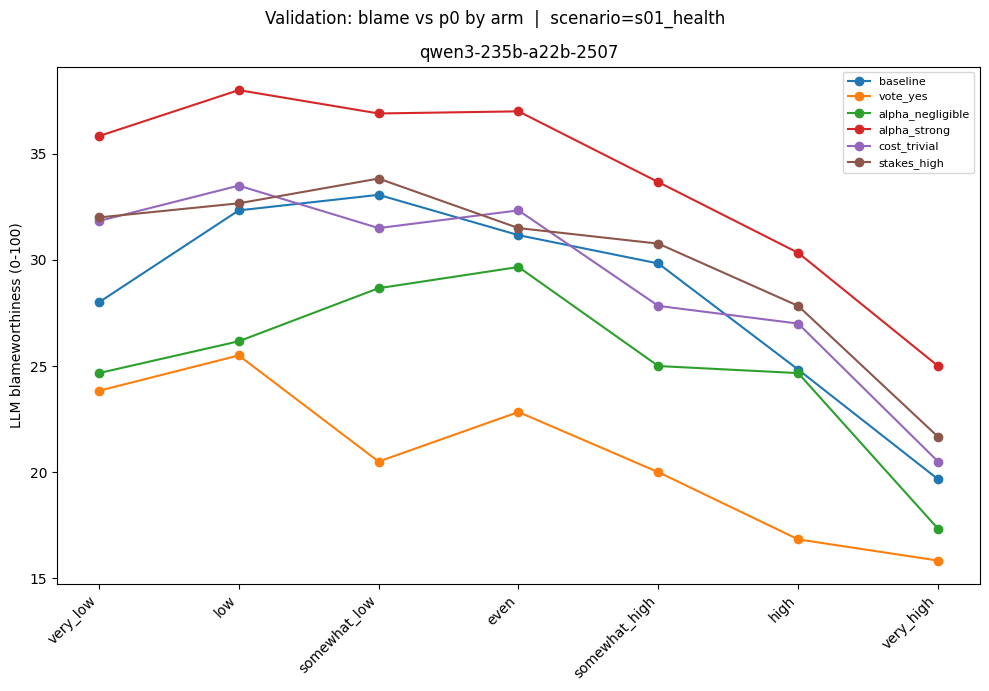

In [13]:
arm_order = [a for a in ["baseline", "vote_yes", "alpha_negligible", "alpha_strong",
                         "cost_trivial", "stakes_high"] if a in ARMS_PRESENT]
models = sorted(val["model_slug"].unique())
# instad, just qwen:
models = ['qwen3-235b-a22b-2507']
fig, axes = plt.subplots(1, len(models), figsize=(10 * len(models), 7),
                         sharey=True, squeeze=False)
for ax, m in zip(axes[0], models):
    g = val[val["model_slug"] == m]
    for arm in arm_order:
        a = g[g["arm"] == arm]
        if a.empty:
            continue
        gm = a.groupby("level_rank")["blameworthiness"].mean()
        ax.plot(gm.index, gm.values, marker="o", label=arm)
    ax.set_title(m); ax.set_xticks(range(len(P0_LEVEL_ORDER)))
    ax.set_xticklabels(P0_LEVEL_ORDER, rotation=45, ha="right")
axes[0][0].set_ylabel("LLM blameworthiness (0-100)")
axes[0][-1].legend(fontsize=8, loc="upper right")
fig.suptitle(f"Validation: blame vs p0 by arm  |  scenario={S}")
savefig("validation_curves")

## 4  Outputs

Tables in `analysis/tables/` (CSV + LaTeX), figures in `analysis/figures/`.
Pull these directly into the report.

In [14]:
print("tables:", sorted(p.name for p in TAB.glob("*.csv")))
print("figures:", sorted(p.name for p in FIG.glob("*.png")))

tables: ['headline_nonmonotonicity.csv', 'headline_spearman.csv', 'headline_variance_shares.csv', 'validation_alpha.csv', 'validation_cost_stakes.csv', 'validation_vote.csv']
figures: ['headline_curves_s01_health.png', 'headline_curves_s02_grant.png', 'headline_curves_s03_board.png', 'validation_curves.png']


## Report Figure: RQ2 Headline — 3×3 normalized blame curves

Clean 3×3 grid (models × scenarios). Both LLM mean blame and FH framework blame are min-max normalized to [0, 1] per cell so shapes are directly comparable.
Saves to `../../report/img/05_rq2_headline.png`.

saved: /home/rcrtss/miis2025/t3/atiis/report/img/04_rq2_headline.png


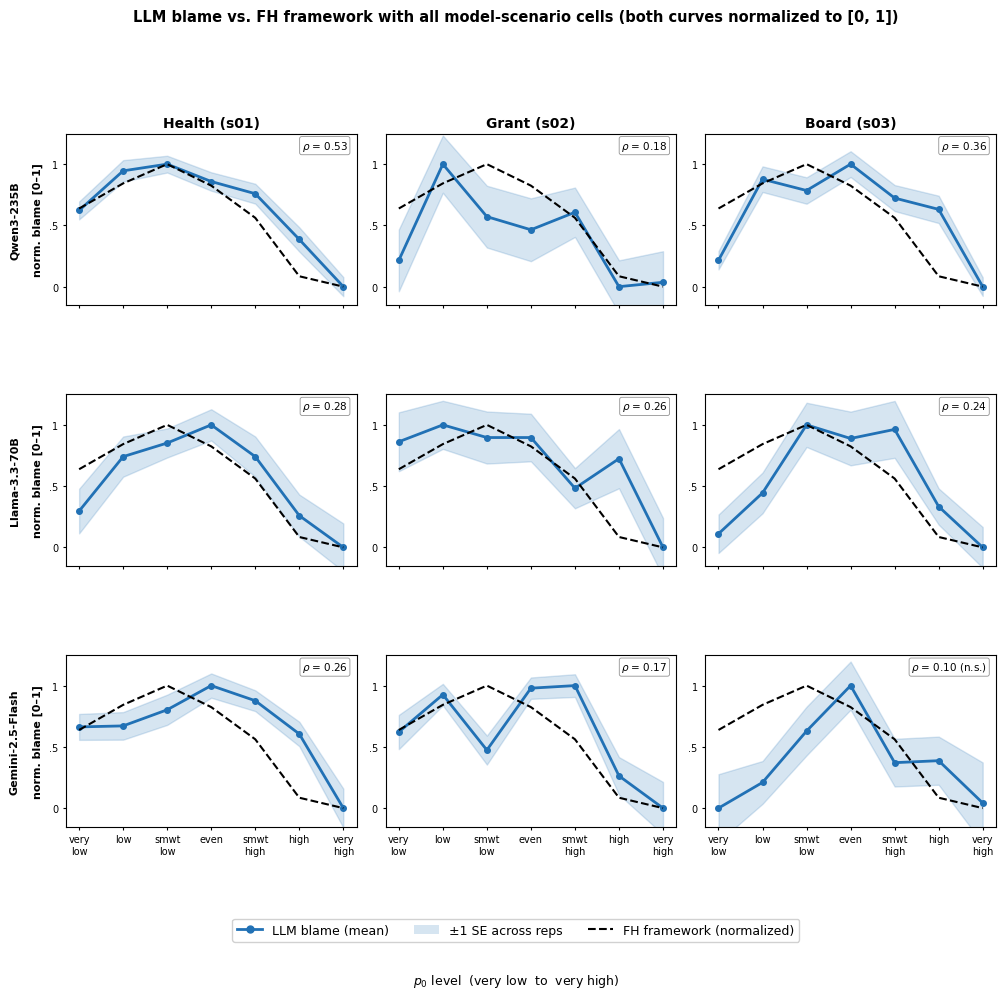

In [25]:
# ── REPORT FIGURE: RQ2 Headline — 3×3 normalized blame curves ────────────────
# Saves to ../../report/img/05_rq2_headline.png

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.patches import Patch
from scipy import stats

HERE = Path.cwd()
EXP_ROOT = HERE if (HERE / "engine").exists() else HERE.parent
sys.path.insert(0, str(EXP_ROOT))
from analysis.loader import load_runs, P0_LEVEL_ORDER

df = load_runs(sweep="sweep1_p0")
base = df[df["arm"] == "baseline"].copy()

# ── Recompute Spearman + BH per cell ─────────────────────────────────────────
def bh_correct(pvals):
    p = np.asarray(pvals, float)
    try:
        return stats.false_discovery_control(p, method="bh")
    except Exception:
        order = np.argsort(p); ranked = np.empty_like(p)
        m = len(p); cummin = 1.0
        for i in range(m - 1, -1, -1):
            cummin = min(cummin, p[order[i]] * m / (i + 1))
            ranked[order[i]] = cummin
        return ranked

sp_rows = []
for (mod, scen), g in base.groupby(["model_slug", "scenario"]):
    r = stats.spearmanr(g["blameworthiness"], g["oracle_at_reference"])
    sp_rows.append({"model": mod, "scenario": scen, "rho": r.statistic, "p": r.pvalue})
sp_df = pd.DataFrame(sp_rows)
sp_df["p_bh"] = bh_correct(sp_df["p"])

# ── Layout config ─────────────────────────────────────────────────────────────
MODEL_ORDER  = ["qwen3-235b-a22b-2507", "llama-3.3-70b-instruct", "gemini-2.5-flash"]
MODEL_LABELS = {"qwen3-235b-a22b-2507":    "Qwen3-235B",
                "llama-3.3-70b-instruct":   "Llama-3.3-70B",
                "gemini-2.5-flash":         "Gemini-2.5-Flash"}
SCEN_ORDER   = ["s01_health", "s02_grant", "s03_board"]
SCEN_LABELS  = {"s01_health": "Health (s01)",
                "s02_grant":  "Grant (s02)",
                "s03_board":  "Board (s03)"}
XTICK        = ["very\nlow", "low", "smwt\nlow", "even", "smwt\nhigh", "high", "very\nhigh"]
X = np.arange(len(P0_LEVEL_ORDER))

def minmax_norm(series):
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn) if mx > mn else pd.Series(np.zeros(len(series)), index=series.index)

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
fig.subplots_adjust(hspace=0.52, wspace=0.10)

for ri, model in enumerate(MODEL_ORDER):
    for ci, scenario in enumerate(SCEN_ORDER):
        ax = axes[ri, ci]
        g = base[(base["model_slug"] == model) & (base["scenario"] == scenario)]

        lm = g.groupby("level_rank")["blameworthiness"].mean()
        ls = g.groupby("level_rank")["blameworthiness"].sem()
        om = g.groupby("level_rank")["oracle_at_reference"].mean()

        lm_scale = lm.max() - lm.min() if lm.max() > lm.min() else 1.0
        lm_n = minmax_norm(lm).values
        ls_n = (ls / lm_scale).values
        om_n = minmax_norm(om).values

        ax.fill_between(X, lm_n - ls_n, lm_n + ls_n, alpha=0.18, color="#2171b5")
        ax.plot(X, lm_n, color="#2171b5", lw=2, marker="o", ms=4)
        ax.plot(X, om_n, color="black", lw=1.5, ls="--")

        row = sp_df[(sp_df["model"] == model) & (sp_df["scenario"] == scenario)].iloc[0]
        sig_str = " (n.s.)" if row["p_bh"] >= 0.05 else ""
        ax.text(0.97, 0.97, f"$\\rho$ = {row['rho']:.2f}{sig_str}",
                transform=ax.transAxes, ha="right", va="top", fontsize=7.5,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.85, lw=0.6))

        if ri == 0:
            ax.set_title(SCEN_LABELS[scenario], fontsize=10, fontweight="bold", pad=5)
        if ci == 0:
            ax.set_ylabel(MODEL_LABELS[model] + "\n\nnorm. blame [0–1]", fontsize=8, fontweight="bold")
        ax.set_xticks(X)
        ax.set_xticklabels(XTICK if ri == 2 else [""] * len(XTICK), fontsize=7)
        ax.set_yticks([0, 0.5, 1])
        ax.set_yticklabels(["0", ".5", "1"], fontsize=7)
        ax.set_ylim(-0.15, 1.25)
        ax.tick_params(length=2)

# Shared legend
h = [mlines.Line2D([], [], color="#2171b5", lw=2, marker="o", ms=5),
     Patch(fc="#2171b5", alpha=0.18),
     mlines.Line2D([], [], color="black", lw=1.5, ls="--")]
fig.legend(h, ["LLM blame (mean)", "±1 SE across reps", "FH framework (normalized)"],
           loc="lower center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.025), framealpha=0.9)
fig.text(0.5, 1.005, "LLM blame vs. FH framework with all model-scenario cells (both curves normalized to [0, 1])",
         ha="center", fontsize=10.5, fontweight="bold")
fig.text(0.5, -0.065, "$p_0$ level  (very low  to  very high)",
         ha="center", fontsize=9)

REPORT_IMG = EXP_ROOT.parent / "report" / "img"
out = str(REPORT_IMG / "04_rq2_headline.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
print(f"saved: {out}")
plt.show()


## Report Figure: RQ2 Validation Arms — 3-panel

Three panels: (a) own vote, (b) pressure effectiveness peak shift, (c) switch cost and stakes. Qwen3-235B / s01_health only.
Saves to `../../report/img/06_rq2_validation.png`.

saved: /home/rcrtss/miis2025/t3/atiis/report/img/04_rq2_validation.png


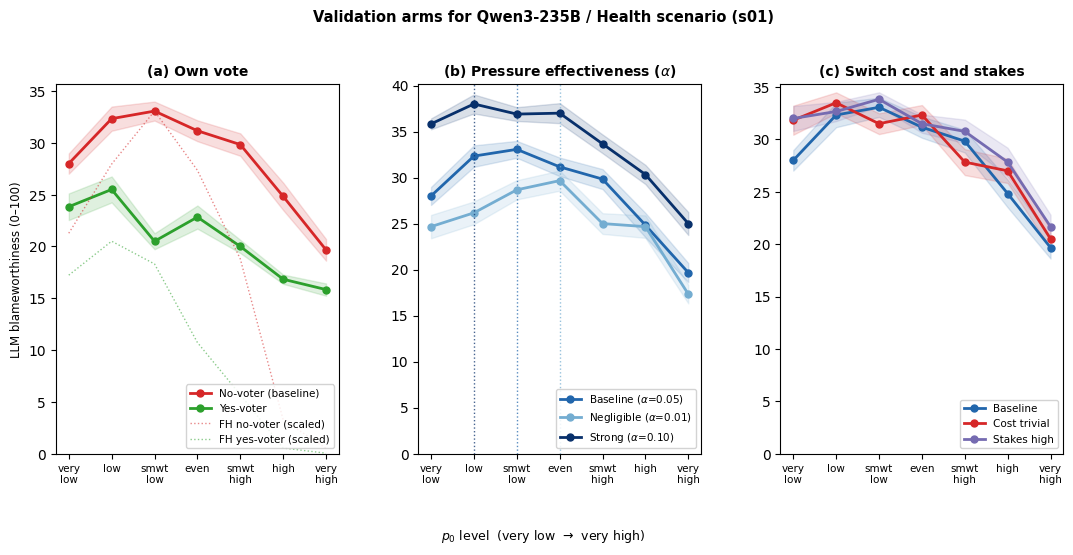

In [24]:

# ── REPORT FIGURE: RQ2 Validation Arms — 3-panel ────────────────────────────
# Saves to ../../report/img/06_rq2_validation.png

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.patches import Patch

HERE = Path.cwd()
EXP_ROOT = HERE if (HERE / "engine").exists() else HERE.parent
sys.path.insert(0, str(EXP_ROOT))
from analysis.loader import load_runs, P0_LEVEL_ORDER

df = load_runs(sweep="sweep1_p0")
val = df[(df["scenario"] == "s01_health") & (df["model_slug"] == "qwen3-235b-a22b-2507")].copy()

X = np.arange(len(P0_LEVEL_ORDER))
XTICK = ["very\nlow", "low", "smwt\nlow", "even", "smwt\nhigh", "high", "very\nhigh"]

def arm_mean(arm, col):
    return val[val["arm"] == arm].groupby("level_rank")[col].mean()

def arm_sem(arm, col):
    return val[val["arm"] == arm].groupby("level_rank")[col].sem()

def plot_arm(ax, arm, label, color, col="blameworthiness", ls="-", lw=2, ms=5):
    m = arm_mean(arm, col)
    s = arm_sem(arm, col)
    ax.fill_between(X, m - s, m + s, alpha=0.15, color=color)
    ax.plot(X, m, color=color, lw=lw, ls=ls, marker="o", ms=ms, label=label)
    return m

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8))
fig.subplots_adjust(wspace=0.28)

# ── (a) Own vote ──────────────────────────────────────────────────────────────
ax = axes[0]
m_no  = plot_arm(ax, "baseline",  "No-voter (baseline)", "#d62728")
m_yes = plot_arm(ax, "vote_yes",  "Yes-voter",           "#2ca02c")

# Scale oracle to LLM peak for visual shape comparison
ora_no  = arm_mean("baseline",  "oracle_at_reference")
ora_yes = arm_mean("vote_yes",  "oracle_at_reference")
scale = m_no.max() / ora_no.max()
ax.plot(X, ora_no  * scale, color="#d62728", lw=1, ls=":", alpha=0.55, label="FH no-voter (scaled)")
ax.plot(X, ora_yes * scale, color="#2ca02c", lw=1, ls=":", alpha=0.55, label="FH yes-voter (scaled)")

ratio_llm = m_no.mean() / max(m_yes.mean(), 1e-6)
# ax.text(0.03, 0.97,
#         f"LLM no/yes ratio: {ratio_llm:.2f}×\n"
#         f"FH predicted ratio: 3.3×\n"
#         f"Yes-voter never assigned 0",
#         transform=ax.transAxes, va="top", fontsize=7.5,
#         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#aaaaaa", alpha=0.92, lw=0.7))
ax.set_title("(a) Own vote", fontsize=10, fontweight="bold")
ax.set_ylabel("LLM blameworthiness (0–100)", fontsize=8.5)
ax.set_xticks(X); ax.set_xticklabels(XTICK, fontsize=7.5)
ax.legend(fontsize=7.5, framealpha=0.85, loc="lower right")
ax.set_ylim(bottom=0)

# ── (b) Pressure effectiveness (α) ───────────────────────────────────────────
ax = axes[1]
arm_cfg_b = [
    ("baseline",         r"Baseline ($\alpha$=0.05)",    "#2166ac"),
    ("alpha_negligible", r"Negligible ($\alpha$=0.01)",  "#74add1"),
    ("alpha_strong",     r"Strong ($\alpha$=0.10)",      "#08306b"),
]
peak_info = {}
for arm, label, color in arm_cfg_b:
    m = plot_arm(ax, arm, label, color)
    peak_rank = int(m.idxmax())
    peak_info[arm] = peak_rank
    ax.axvline(peak_rank, color=color, lw=1, ls=":", alpha=0.75)

# Annotate peak shift match
# annot = (
#     "Peak shift matches FH:\n"
#     f"  Baseline:    rank {peak_info['baseline']+1}/7\n"
#     f"  Negligible:  rank {peak_info['alpha_negligible']+1}/7  (FH: 3)  ✓\n"
#     f"  Strong:      rank {peak_info['alpha_strong']+1}/7  (FH: 1)  ✓"
# )
# ax.text(0.97, 0.97, annot, transform=ax.transAxes, ha="right", va="top", fontsize=7,
#         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#aaaaaa", alpha=0.92, lw=0.7),
#         family="monospace")
ax.set_title(r"(b) Pressure effectiveness ($\alpha$)", fontsize=10, fontweight="bold")
ax.set_xticks(X); ax.set_xticklabels(XTICK, fontsize=7.5)
ax.legend(fontsize=7.5, framealpha=0.85, loc="lower right")
ax.set_ylim(bottom=0)

# ── (c) Switch cost and stakes ────────────────────────────────────────────────
ax = axes[2]
arm_cfg_c = [
    ("baseline",     "Baseline",      "#2166ac"),
    ("cost_trivial", "Cost trivial",  "#d62728"),
    ("stakes_high",  "Stakes high",   "#756bb1"),
]
for arm, label, color in arm_cfg_c:
    plot_arm(ax, arm, label, color)

# ax.text(0.03, 0.05,
#         "Cost trivial:  no shift  (p = 0.32, n.s.)\n"
#         "Stakes high:   weak shift  (p = 0.04)",
#         transform=ax.transAxes, va="bottom", fontsize=7.5,
#         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#aaaaaa", alpha=0.92, lw=0.7))
ax.set_title("(c) Switch cost and stakes", fontsize=10, fontweight="bold")
ax.set_xticks(X); ax.set_xticklabels(XTICK, fontsize=7.5)
ax.legend(fontsize=7.5, framealpha=0.85, loc="lower right")
ax.set_ylim(bottom=0)

fig.text(0.5, 1.01,
         "Validation arms for Qwen3-235B / Health scenario (s01)",
         ha="center", fontsize=10.5, fontweight="bold")
fig.text(0.5, -0.07, "$p_0$ level  (very low  →  very high)", ha="center", fontsize=9)

REPORT_IMG = EXP_ROOT.parent / "report" / "img"
out = str(REPORT_IMG / "04_rq2_validation.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
print(f"saved: {out}")
plt.show()
